In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from matplotlib.ticker import PercentFormatter
from matplotlib.ticker import ScalarFormatter
import plotnine as p9

DATA_ROOT = "./data"

In [16]:
data = pd.read_parquet(f"{DATA_ROOT}/olhcv_merged.parquet")

data = data[["permno","ticker","date", "ret", "mcap", "close", "sic2"]].copy()

data["date"] = pd.to_datetime(data["date"])
data["ret"] = data["ret"].astype("float64")
data["mcap"] = data["mcap"].astype("float64")


data.head(5)

,permno,ticker,date,ret,mcap,close,sic2
0,10032,PLXS,2001-02-01,0.049268,2.022550e+09,49.25,36
1,10078,SUNW,2001-02-01,0.018405,1.014634e+11,124.5,35
2,10104,ORCL,2001-02-01,0.032189,1.679267e+11,30.0625,73
3,10107,MSFT,2001-02-01,0.021494,3.327950e+11,31.1875,73
4,10108,SDS,2001-02-01,-0.009009,6.531574e+09,24.75,73


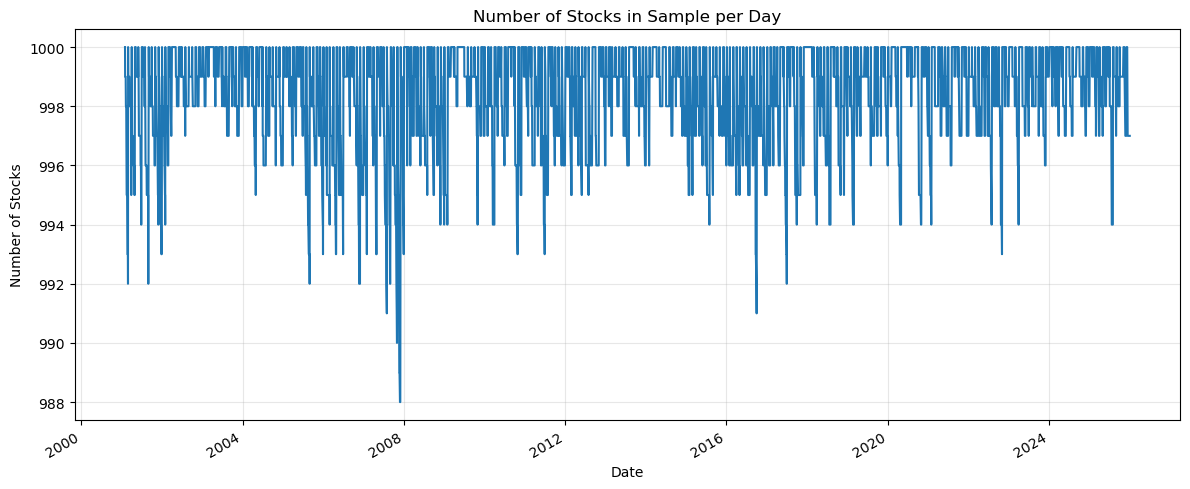

In [17]:
# Count distinct stocks per day
stocks_per_day = data.groupby("date")["permno"].nunique()

# Plot
fig, ax = plt.subplots(figsize=(12, 5))
stocks_per_day.plot(ax=ax)
ax.set_title("Number of Stocks in Sample per Day")
ax.set_xlabel("Date")
ax.set_ylabel("Number of Stocks")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### **Constructing data universe**

Each day, keep the top 500 stocks by mcap. If any of these stocks has any missing return for the past 504 (or defined window size) days, then discard that stock and keep the next available stock by market cap that satisfies the window requirement.



In [18]:
N_STOCKS = 500
WINDOW = 504

# Pivot returns and marketcap
ret_wide = data.pivot(index="date", columns="permno", values="ret").sort_index()
mcap_wide = data.pivot(index="date", columns="permno", values="mcap").sort_index()

# For each day, does each stock have a FULL 504-day trailing history (no gaps)?
has_full_history = ret_wide.notna().rolling(WINDOW).sum() == WINDOW

dates = ret_wide.index

universe = {} 

for t in dates:
    eligible_mask = has_full_history.loc[t]
    eligible = eligible_mask[eligible_mask].index      # stocks with full history as of t

    if len(eligible) == 0:
        continue

    mcap_t = mcap_wide.loc[t, eligible].dropna()
    top500 = mcap_t.nlargest(N_STOCKS).index           # largest 500 stocks that satisfy requirements

    universe[t] = list(top500)


# Diagnostics: how many eligible names per day, and how many days actually hit 500
eligible_count = has_full_history.sum(axis=1)
selected_count = pd.Series({t: len(v) for t, v in universe.items()})

# First date where a full 504-day window is even possible
burn_in_date = dates[WINDOW - 1]

# Restrict diagnostics to dates on/after burn-in
eligible_count_post = eligible_count.loc[burn_in_date:]
selected_count_post = selected_count.loc[burn_in_date:]  # universe dict already only has post-burn-in dates

print(eligible_count_post.describe())
print("\nDays with fewer than 500 eligible names:", 
      (eligible_count_post < N_STOCKS).sum(), "out of", len(eligible_count_post))

count    5763.000000
mean      767.655908
std        27.215623
min       677.000000
25%       752.000000
50%       773.000000
75%       784.000000
max       825.000000
dtype: float64

Days with fewer than 500 eligible names: 0 out of 5763


## **PCA**

#### **Functions**

In [19]:
HALFLIFE = 252

# Exponentially-weighted covariance matrix
def ewma_cov(X, halflife):
    T = X.shape[0]
    beta = np.exp(np.log(0.5) / halflife)
    lags = np.arange(T - 1, -1, -1)      # newest row -> lag 0
    w = beta ** lags
    w /= w.sum()

    wmean = (w[:, None] * X).sum(axis=0)
    Xc = X - wmean
    cov = (Xc * w[:, None]).T @ Xc

    cov /= (1 - np.sum(w**2))            # bias correction (sample covariance matrix)

    return cov


# Exponentially-weighted mean and std for standarization of returns
def ewma_mean_std(X, halflife):
    T = X.shape[0]
    beta = np.exp(np.log(0.5) / halflife)
    lags = np.arange(T - 1, -1, -1)
    w = beta ** lags
    w /= w.sum()

    mean = (w[:, None] * X).sum(axis=0)
    var = (w[:, None] * (X - mean)**2).sum(axis=0) / (1 - np.sum(w**2))
    return mean, np.sqrt(var)


'''
pca_results = {}  # date -> dict of PCA outputs

for t, permnos in universe.items():
    i = dates.get_loc(t)
    window_dates = dates[i - WINDOW + 1 : i + 1]

    R = ret_wide.loc[window_dates, permnos].values   # (504, 500), no NaNs by construction
    R_std = (R - R.mean(axis=0)) / R.std(axis=0)

    cov = ewma_cov(R_std, HALFLIFE)                   # (500, 500)

    eigvals, eigvecs = np.linalg.eigh(cov)           
    eigvals, eigvecs = eigvals[::-1], eigvecs[:, ::-1]

    sigma_plain = R.std(axis=0) 

    explained_var_ratio = eigvals / eigvals.sum()

    pca_results[t] = {
        "permnos": permnos,
        "eigvals": eigvals.astype(np.float32),
        "eigvecs": eigvecs.astype(np.float32),
        "sigma": sigma_plain.astype(np.float32),
        "explained_var_ratio": explained_var_ratio.astype(np.float32),
    }
'''


'\npca_results = {}  # date -> dict of PCA outputs\n\nfor t, permnos in universe.items():\n    i = dates.get_loc(t)\n    window_dates = dates[i - WINDOW + 1 : i + 1]\n\n    R = ret_wide.loc[window_dates, permnos].values   # (504, 500), no NaNs by construction\n    R_std = (R - R.mean(axis=0)) / R.std(axis=0)\n\n    cov = ewma_cov(R_std, HALFLIFE)                   # (500, 500)\n\n    eigvals, eigvecs = np.linalg.eigh(cov)           \n    eigvals, eigvecs = eigvals[::-1], eigvecs[:, ::-1]\n\n    sigma_plain = R.std(axis=0) \n\n    explained_var_ratio = eigvals / eigvals.sum()\n\n    pca_results[t] = {\n        "permnos": permnos,\n        "eigvals": eigvals.astype(np.float32),\n        "eigvecs": eigvecs.astype(np.float32),\n        "sigma": sigma_plain.astype(np.float32),\n        "explained_var_ratio": explained_var_ratio.astype(np.float32),\n    }\n'

#### **Implementation**

In [20]:

pca_results = {}  

for t, permnos in universe.items():
    i = dates.get_loc(t)
    window_dates = dates[i - WINDOW + 1 : i + 1]

    R = ret_wide.loc[window_dates, permnos].values 

    # Standarize returns (using ewma calculations)
    ewma_mean, ewma_sigma = ewma_mean_std(R, HALFLIFE)
    R_std = (R - ewma_mean) / ewma_sigma 

    # EWMA Covariance of standarized returns
    cov = ewma_cov(R_std, HALFLIFE)          

    # PCA decomposition
    eigvals, eigvecs = np.linalg.eigh(cov)           
    eigvals, eigvecs = eigvals[::-1], eigvecs[:, ::-1]

    # Explained variance ratio for each eigenvalue
    explained_var_ratio = eigvals / eigvals.sum()

    pca_results[t] = {
        "permnos": permnos,
        "eigvals": eigvals.astype(np.float32),
        "eigvecs": eigvecs.astype(np.float32),
        "sigma": ewma_sigma.astype(np.float32),
        "explained_var_ratio": explained_var_ratio.astype(np.float32),
    }

#### **PCA plots**

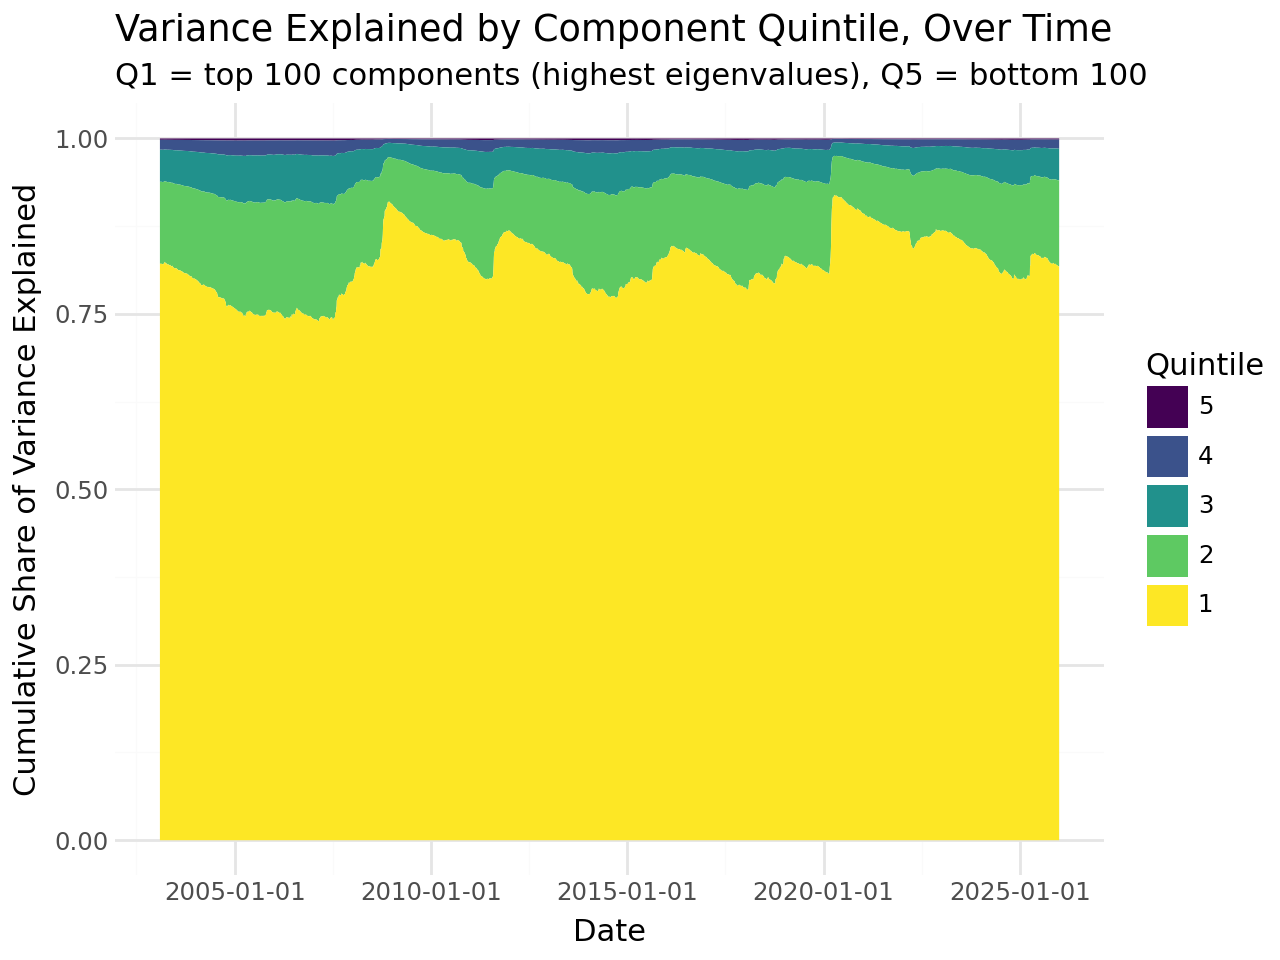

In [21]:
N_QUINTILES = 5

records = []
for t, res in pca_results.items():
    evr = res["explained_var_ratio"]          # length 500, full rank, sums to 1
    n = len(evr)
    q_size = n // N_QUINTILES

    for q in range(N_QUINTILES):
        start = q * q_size
        end = (q + 1) * q_size if q < N_QUINTILES - 1 else n
        records.append({
            "date": t,
            "quintile": q + 1,
            "var_explained": evr[start:end].sum()
        })

df_q = pd.DataFrame(records)

# Reverse order (5,4,3,2,1) so Q1 (largest eigenvalues) stacks at the BOTTOM of the chart
df_q["quintile"] = pd.Categorical(df_q["quintile"], categories=[5, 4, 3, 2, 1], ordered=True)

p = (
    p9.ggplot(df_q, p9.aes(x="date", y="var_explained", fill="quintile"))
    + p9.geom_area(position="stack")
    + p9.labs(
        title="Variance Explained by Component Quintile, Over Time",
        subtitle="Q1 = top 100 components (highest eigenvalues), Q5 = bottom 100",
        x="Date",
        y="Cumulative Share of Variance Explained",
        fill="Quintile"
    )
    + p9.theme_minimal()
)
p

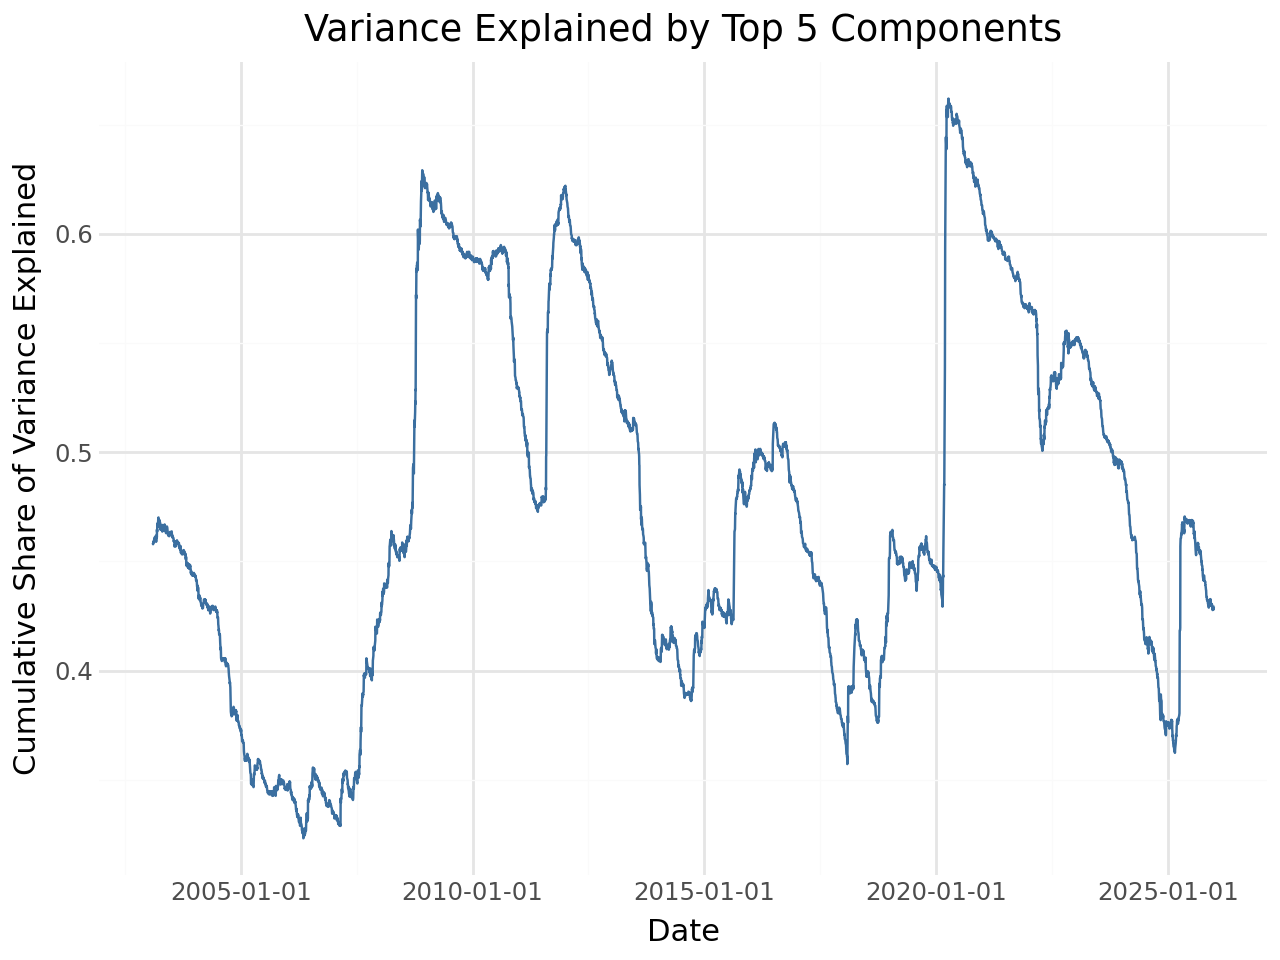

In [22]:
top_n = 5

records_topn = []
for t, res in pca_results.items():
    evr = res["explained_var_ratio"]         # length 500, sorted descending, sums to 1
    records_topn.append({
        "date": t,
        "var_topn": evr[:top_n].sum()
    })

df_top100 = pd.DataFrame(records_topn)

p1 = (
    p9.ggplot(df_top100, p9.aes(x="date", y="var_topn"))
    + p9.geom_line(color="#3b6fa0")
    + p9.labs(
        title=f"Variance Explained by Top {top_n} Components",
        x="Date",
        y="Cumulative Share of Variance Explained"
    )
    + p9.theme_minimal()
)
p1

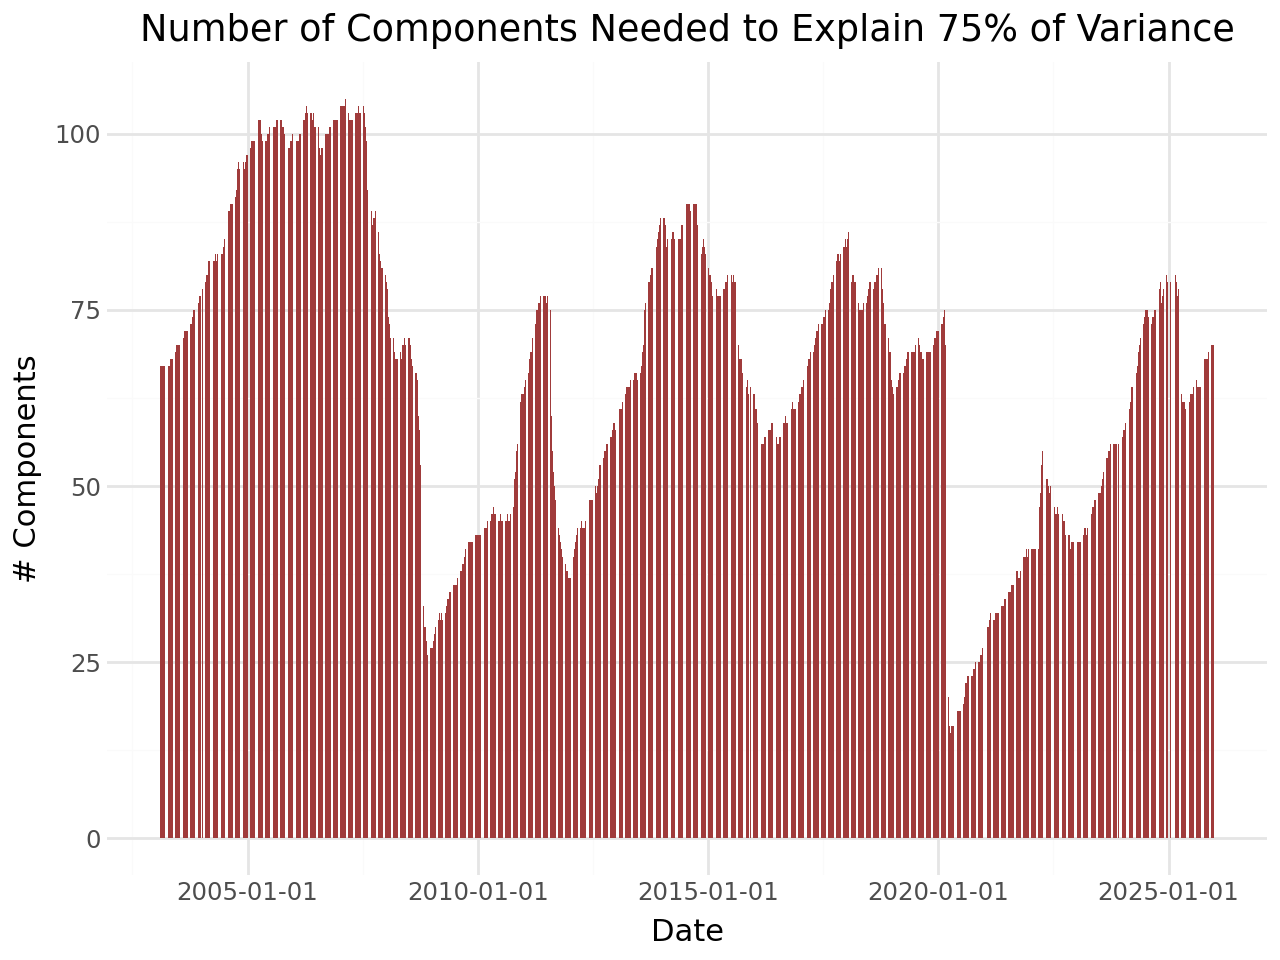

In [23]:
THRESHOLD = 0.75

records_n75 = []
for t, res in pca_results.items():
    evr = res["explained_var_ratio"]
    cum = np.cumsum(evr)                      # running total: cum[k] = variance explained by first k+1 PCs
    n_needed = int(np.searchsorted(cum, THRESHOLD, side="left") + 1)
    records_n75.append({"date": t, "n_components_75": n_needed})

df_n75 = pd.DataFrame(records_n75)

p2 = (
    p9.ggplot(df_n75, p9.aes(x="date", y="n_components_75"))
    + p9.geom_col(fill="#a03b3b", width=1.0)
    + p9.labs(
        title="Number of Components Needed to Explain 75% of Variance",
        x="Date",
        y="# Components"
    )
    + p9.theme_minimal()
)
p2

## **Measuring diversification of a given portfolio**

Before defining and measuring the diversification of a given portfolio construction method, we need to project the portfolio's weights onto the eigenspace and compute the portfolio's score on each principal component. Our measures of diversification will use the scores as input.

We performed the PCA decomposition on standarized returns (correlation matrix), but we are interested in measuring the diversification of a portfolio in the real world, where assets have different volatilities. In other words, our eigenvectors and real world portfolios live in different spaces. Before projecting the portfolio onto the eigenvectors, we therefore need to re-express the portfolio's weights in standardized returns units, so that the resulting variance decomposition is measured in a consistent space.

The end goal is to rxpress the portfolio variance in terms of the uncorrelated sources of risk. Let's start by expresing the portfolio's variance in terms of the raw covariance matrix:

$$
\sigma_p^2 = w^\top \Sigma w
$$

where $\sigma_p^2$ is the portfolio's variance, $w$ is the vector of weights, and $\Sigma$ is the raw covariance matrix. 

The covariance matrix can be expressed in terms of the correlation matrix:

$$
\Sigma = D\,C\,D
$$

where $C$ is the correlation matrix and $D = \text{diag}(\sigma_1, \dots, \sigma_N)$.

Substituting, we have:

$$
\sigma_p^2 = w^\top \Sigma w = w^\top (D C D) w = (w^\top D)\, C\, (D w) = (Dw)^\top\, C\, (D w)
$$

The last step follows since $D$ is diagonal (and thus, symmetric), so $ w^\top D = (D^\top w)^\top = (Dw)^\top$.

The term $Dw$ is multiplying a diagonal matrix of the volatilities by the vector of weights, which results in a vector of weights scaled by the volatility. In other words, the entries of this resulting vector are the original portfolio weights multiplied by the each asset volatility ($\sigma_i w_i$). We will define $u := Dw$, so $u_i = \sigma_i w_i$.

-----

Now, we want to decompose the variance of the portfolio using the principal components.

In the steps above, we showed that 

$$
\sigma_p^2 = u^\top C u
$$

We have already decomposed the correlation matrix, so the equation above becomes:


$$
\sigma_p^2 = u^\top (V \Lambda V^\top) u
$$

where $V$ is the matrix of eigenvectors and $\Lambda = \text{diag}(\lambda_1, \dots, \lambda_N)$.

Rearranging:

$$
\sigma_p^2 = u^\top (V \Lambda V^\top) u = (u^\top V) \Lambda (V^\top u) = (V^\top u)^\top \Lambda (V^\top u)
$$

The term $V^\top u$ is the projection of the portfolio weights on the eigenvectors. We can further define $s = V^\top u$ and the portfolio variance becomes:

$$
\sigma_p^2 = s^\top \Lambda s = \sum_{k=1}^N \lambda_k s_k^2
$$

where the last term comes from the vector and matrix multiplication, given that the matrix $\Lambda$ is diagonal.

In plain words, the portfolio variance is the sum of the product of eigenvalues and the squared projection of the portfolio weights on the eigenvectors (the square of the scores). Each term $\lambda_k s_k^2$ is the portfolio variance attributable to component $k$.

----

For our diversification measures, we are interested in the fraction of portfolio variance explained by each component:

$$
p_k = \frac{\lambda_k\, s_k^2}{\sum_{j=1}^{N} \lambda_j\, s_j^2}
$$


The distribution of $\{p_k\}$ is the input for the diversification measures.


## **Diversification measures**

Intuitively, the concept of diversification is closely related to the fraction of portfolio variance explained by each component. A highly diversified portfolio should have a similar fraction of variance explained by each component, while a portfolio with low diversification should have a large portion of the variance explained by a few components. We can try to measure diversification by assesing how concentrated is the variance explained by the components.


1. **Entropy-based measure of diversification (Meucci, 2010):**

$$
N_{ent} = \exp\left(-\sum_k p_k\ln p_k\right)
$$

This formula measures the dispersion of the distribution of $\{p_k\}$. For a completely concentrated portfolio, $N_{ent} = 0$. For a completely diversified portfolio, $N_{ent} = K$. In essence, $N_{ent}$ is the effective number of uncorrelated risk sources.


2. **Herfindahl–Hirschman index measure of diversification**


$$
N_{HHI} = \frac{1}{\sum_k p_k^2}
$$

We use the inverse instead of the raw HHI (\sum_k p_k^2) to be consistent with the $N_{ent}$ measure. Higher $N_{HHI}$ reflects more diversification.


3. **Fraction of variance explained by top N components**

$$
\ {Var}_{topN} = \sum_{k=1}^{N} p_k
$$

This is an equivalent measure to the Absorption Ratio in (Kritzman, Li, Page & Rigobon, 2010).

#### **Code - diversification measures**

In [24]:

### Calculate the fraction of portfolio variance explained by each component
# Important: weights must be a dictionary {permno: weight}
def get_portfolio_variance_shares(weights, pca_result):

    permnos = pca_result["permnos"]
    eigvecs = pca_result["eigvecs"].astype(np.float64)
    eigvals = pca_result["eigvals"].astype(np.float64)
    sigma   = pca_result["sigma"].astype(np.float64)

    # Align the weights so that they match the eigenvectors stock order
    w = np.array([weights.get(p, 0.0) for p in permnos])   

    # Scale the portfolio weight by the volatility
    u = w * sigma      

    # Project the scaled weights onto each component
    scores = eigvecs.T @ u                                  

    # Contribution of variance of each component
    var_contrib = eigvals * scores**2
    total_var = var_contrib.sum()

    if total_var <= 0:
        return None, 0.0

    # Fraction of variance explained by each component
    p_k = var_contrib / total_var

    return p_k, total_var


# Entropy-based measure of diversification
def n_entropy(p_k):
    nonzero = p_k > 0                      # avoid 0 * log(0)
    entropy = -np.sum(p_k[nonzero] * np.log(p_k[nonzero]))
    return np.exp(entropy)

# HHI-based measure of diversification
def n_hhi(p_k):
    return 1.0 / np.sum(p_k**2)

# Variance explained by top N components measure
def top_n_var_explained(p_k, n=10):
    return np.sum(p_k[:n])

# Wrapper function
def compute_diversification_measures(weights, pca_result, top_n=10):

    p_k, total_var = get_portfolio_variance_shares(weights, pca_result)
    
    if p_k is None:
        return None

    return {
        "portfolio_variance": total_var,
        "p_k": p_k,
        "enb_entropy": n_entropy(p_k),
        "enb_hhi": n_hhi(p_k),
        f"top_{top_n}_var_explained": top_n_var_explained(p_k, top_n),
    }

#### **Methodological Choices - Discussion**

- Shrink covariance matrix?
- Lookback window for covariance.
- Exponentially-weighted covariance or simple covariance?
- Standarize returns using exponentially-weighted variance or simple variance?

#### **Next steps - possible paths for the project**

- Determine which portfolio construction methods we want to evaluate. Equal-risk contribution, minimum variance portfolio, maximum diversification portfolio, naive equal-weight portfolio, marketcap-weighted portfolio. I would avoid mean-variance portfolios as they are super noisy and rely on expected returns. All other methods only require covariance.
- Build the functions for each portfolio construction method and determine the weights each day. Store the weights in a dictionary {permno: weight} (this is what the diversification calculation function expects).
- Compare diversification measures between methods, both in general and accross time. It would be interesting to focus also on specific periods to see if any method is more diversified that the others in that specific period but less diversified in other periods.
- Does a change in the diversification measure anticipates downturns or stress periods in markets? Similar to what Kritzman et al. (2010) but focused on the the diversification of the portfolios. I'm not sure if it's going too far, but was thinking that changes in the most diversified portfolio could anticipate downturns, whereas changes in the less diversified portfolio are perhaps not predictive? 
- Happy to take other directions also, but this is what I thought was interesting.
